# Consensus MOFA-FLEX

Like any stochastic optimisation, fitting a non-negative MOFA-FLEX model
twice with different random seeds yields slightly different factor and
weight matrices. *Consensus MOFA-FLEX* aggregates many such fits into a
single, more stable factorisation, and provides a principled way to
choose the number of factors $k$.

This vignette walks through the
[`fit_consensus`](#mofaflex.tl.fit_consensus) /
[`k_selection`](#mofaflex.tl.k_selection) API recently added to
`mofaflex.tl`, which ports the consensus-NMF recipe of
{cite:p}`kotliar2019identifying` (see the
[cNMF package](https://github.com/dylkot/cNMF)) to the multi-view
MOFA-FLEX setting. The pipeline:

1. Runs `n_runs` independent MOFA-FLEX fits with distinct random seeds.
2. Pools the per-view weight columns into one stacked spectra matrix and
   normalises them so views contribute comparably to Euclidean distances.
3. Filters outlier spectra by *local density* (mean distance to a
   nearest-neighbour set).
4. Clusters the survivors with k-means and takes per-cluster median
   weight vectors as the consensus weights.
5. Refits per-group factor (usage) matrices against the fixed consensus
   weights via non-negative least squares.

```{note}
Only fully non-negative templates are supported: the
[`MofaFlex`](#mofaflex.terms.MofaFlex) term must be configured with
`nonnegative_factors=True` **and** `nonnegative_weights=True`. Consensus
is taken in the non-negative weight space.
```

## Setup

In [1]:
import anndata as ad
import numpy as np
import pandas as pd

import mofaflex as mfl
from mofaflex import terms
from mofaflex.tl import DataGenerator, fit_consensus, k_selection

from plotnine import theme_set, theme_bw

theme_set(theme_bw())

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

## A small synthetic two-view dataset

To keep the vignette self-contained and CI-friendly, we use the in-repo
[`DataGenerator`](#mofaflex.tl.DataGenerator) to simulate a small,
fully non-negative two-view dataset with a known ground truth of **5
factors** (3 fully shared + 1 partially shared + 1 private). We then
wrap the views as `AnnData` objects in the nested
`{group: {view: AnnData}}` dict that
[`MOFAFLEX.fit`](#mofaflex.MOFAFLEX.fit) accepts directly.

In [3]:
gen = DataGenerator(
    n_features=[40, 50],
    n_samples=200,
    likelihoods=["Normal", "Normal"],
    n_fully_shared_factors=3,
    n_partially_shared_factors=1,
    n_private_factors=1,
    factor_size_params=(0.4, 0.6),
    n_active_factors=1.0,
    nmf=[True, True],
)
gen.generate(np.random.default_rng(0))

ys = gen._ys
obs_names = [f"cell_{i}" for i in range(gen.n_samples)]
data = {"group_1": {}}
for m in range(gen.n_views):
    data["group_1"][f"view_{m}"] = ad.AnnData(
        ys[m].astype(np.float32, copy=False),
        obs=pd.DataFrame(index=obs_names),
        var=pd.DataFrame(
            index=[f"view{m}_feature_{j}" for j in range(gen.n_features[m])]
        ),
    )

{group: {view: ad.shape for view, ad in views.items()} for group, views in data.items()}

{'group_1': {'view_0': (200, 40), 'view_1': (200, 50)}}

## A single non-negative fit, for reference

A standard non-negative MOFA-FLEX fit on this dataset would look like
this. We use it only as a baseline; running this same cell with a
different `seed` would produce slightly different weights — that
run-to-run variability is exactly what consensus aggregation tames.

In [4]:
single = terms.MofaFlex(
    n_factors=5, nonnegative_factors=True, nonnegative_weights=True
)
single.fit(
    data,
    max_epochs=200,
    device="cpu",
    lr=0.01,
    early_stopper_patience=20,
    save_path=False,
    plot_data_overview=False,
    seed=0,
)
single.get_weights()["view_0"].shape, single.get_factors()["group_1"].shape

WARNING	Could not import dask. Data arrays may be copied, resulting in high memory usage.


INFO	No likelihoods provided. Using inferred likelihoods: view_0: Normal; view_1: Normal


INFO	Initializing factors using 'random' method...


  0%|          | 0/200 [00:00<?, ?epoch/s]

((40, 5), (200, 5))

## Running consensus MOFA-FLEX

[`fit_consensus`](#mofaflex.tl.fit_consensus) takes a *factory* — a
zero-argument callable that returns a fresh, untrained MOFA-FLEX
template — plus the data and a few aggregation parameters. It then
takes care of running all replicates, pooling their weights, density-
filtering, clustering, and refitting the consensus factor matrices.

The key parameters (full docstring at
[`mofaflex.tl.fit_consensus`](#mofaflex.tl.fit_consensus)):

- `n_runs`: number of independent replicate fits. Defaults to 30; in
  practice 20–50 is typical. Here we use 6 to keep the vignette fast.
- `density_threshold`: strict upper bound on per-spectrum local density
  used for outlier filtering. Smaller is stricter; the cNMF default of
  `0.5` is a good starting point.
- `local_neighborhood_size`: fraction of `n_runs` used as the
  nearest-neighbour count for local density. Default `0.30`.
- `seed`: master seed for drawing the per-replicate seeds, so the whole
  pipeline is reproducible.
- `fit_kwargs`: extra keyword arguments forwarded to
  [`MOFAFLEX.fit`](#mofaflex.MOFAFLEX.fit). The `seed` and
  `plot_data_overview` keys are managed internally.

In [5]:
def template_factory():
    return terms.MofaFlex(
        n_factors=5,
        nonnegative_factors=True,
        nonnegative_weights=True,
    )


result = fit_consensus(
    template_factory,
    data,
    n_runs=6,
    density_threshold=0.5,
    seed=42,
    fit_kwargs={
        "max_epochs": 200,
        "device": "cpu",
        "lr": 0.01,
        "early_stopper_patience": 20,
        "save_path": False,
    },
    show_progress=False,
)
result

INFO	No likelihoods provided. Using inferred likelihoods: view_0: Normal; view_1: Normal


INFO	Initializing factors using 'random' method...


  0%|          | 0/200 [00:00<?, ?epoch/s]

INFO	No likelihoods provided. Using inferred likelihoods: view_0: Normal; view_1: Normal


INFO	Initializing factors using 'random' method...


...

INFO	No likelihoods provided. Using inferred likelihoods: view_0: Normal; view_1: Normal


INFO	Initializing factors using 'random' method...


  0%|          | 0/200 [00:00<?, ?epoch/s]

/usr/local/lib/python3.11/dist-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.


ConsensusResult(n_factors=5, view_names=('view_0', 'view_1'), group_names=('group_1',), consensus_weights={'view_0':                   Factor 1  Factor 2  Factor 3  Factor 4  Factor 5
view0_feature_0   0.146239  0.148845  0.140757  0.140844  0.145355
view0_feature_1   0.119901  0.113438  0.117634  0.116437  0.130840
view0_feature_2   0.000000  0.023404  0.000000  0.015032  0.005191
view0_feature_3   0.175479  0.182135  0.173008  0.168984  0.166791
view0_feature_4   0.091478  0.062520  0.075560  0.085210  0.105920
view0_feature_5   0.000000  0.029096  0.003205  0.006149  0.000509
view0_feature_6   0.172697  0.168925  0.168538  0.161896  0.163098
view0_feature_7   0.002068  0.000000  0.001374  0.049408  0.023370
view0_feature_8   0.146250  0.136450  0.133627  0.140008  0.145670
view0_feature_9   0.051298  0.051972  0.054914  0.059870  0.081722
view0_feature_10  0.161022  0.161148  0.158193  0.156251  0.155953
view0_feature_11  0.098781  0.083850  0.083819  0.096396  0.098868
view0_featur

## Inspecting the `ConsensusResult`

The returned [`ConsensusResult`](#mofaflex.tl.ConsensusResult) carries
both the consensus factorisation and the diagnostic bookkeeping needed
to reason about its quality.

In [6]:
print(f"n_factors:            {result.n_factors}")
print(f"view_names:           {result.view_names}")
print(f"group_names:          {result.group_names}")
print(f"per-run seeds:        {result.per_run_seeds}")
print(f"stability (silhouette): {result.stability:.4f}")
print(f"reconstruction error: {result.reconstruction_error:.2f}")
print(f"density threshold:    {result.density_threshold}")
print(f"# spectra kept:       {int(result.kept_mask.sum())} / {len(result.kept_mask)}")

n_factors:            5
view_names:           ('view_0', 'view_1')
group_names:          ('group_1',)
per-run seeds:        (191664964, 1662057957, 1405681632, 942484272, 929893138, 1843824992)
stability (silhouette): 0.1003
reconstruction error: 11713.54
density threshold:    0.5
# spectra kept:       30 / 30


The two main outputs are `consensus_weights` (one DataFrame per view,
shape `(n_features[view], n_factors)`) and `consensus_factors` (one
DataFrame per group, shape `(n_samples[group], n_factors)`). Both are
non-negative by construction, and the factor columns are sorted by
total usage contribution (descending) so the most-explanatory factor
is always `Factor 1`.

In [7]:
for view, W in result.consensus_weights.items():
    print(view, W.shape)
result.consensus_weights["view_0"].head()

view_0 (40, 5)
view_1 (50, 5)


,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
view0_feature_0,0.146239,0.148845,0.140757,0.140844,0.145355
view0_feature_1,0.119901,0.113438,0.117634,0.116437,0.130840
view0_feature_2,0.000000,0.023404,0.000000,0.015032,0.005191
view0_feature_3,0.175479,0.182135,0.173008,0.168984,0.166791
view0_feature_4,0.091478,0.062520,0.075560,0.085210,0.105920


In [8]:
for group, Z in result.consensus_factors.items():
    print(group, Z.shape)
result.consensus_factors["group_1"].head()

group_1 (200, 5)


,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
cell_0,13.131484,4.511259,0.000000,0.000000,0.0
cell_1,0.000000,2.109225,0.000000,9.826008,0.0
cell_2,0.000000,7.273105,4.274248,0.000000,0.0
cell_3,5.496551,8.247204,0.000000,0.000000,0.0
cell_4,5.014725,0.000000,0.000000,4.930055,0.0


A quick sanity check: the top-loading features of each consensus
factor in `view_0`.

In [9]:
result.consensus_weights["view_0"].apply(
    lambda col: col.nlargest(5).index.tolist()
)

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
0,view0_feature_32,view0_feature_19,view0_feature_32,view0_feature_32,view0_feature_32
1,view0_feature_19,view0_feature_3,view0_feature_19,view0_feature_19,view0_feature_19
2,view0_feature_3,view0_feature_32,view0_feature_3,view0_feature_3,view0_feature_3
3,view0_feature_35,view0_feature_21,view0_feature_35,view0_feature_35,view0_feature_35
4,view0_feature_6,view0_feature_6,view0_feature_21,view0_feature_21,view0_feature_6


## Diagnostic clustergram

[`ConsensusResult.plot_clustergram`](#mofaflex.tl.ConsensusResult.plot_clustergram)
renders a faithful port of cNMF's diagnostic clustergram. It has five
panels:

- a heatmap of pairwise Euclidean distances between the **kept**
  L2-normalised spectra, reordered so members of each k-means cluster
  are contiguous and within-cluster ordering follows average-linkage
  hierarchical clustering;
- left and top cluster-label sidebars;
- a colorbar for the distance heatmap;
- a histogram of *all* per-spectrum local densities, with a vertical
  dashed line at the chosen `density_threshold`.

What to look for: tight, dark blocks down the diagonal indicate stable
factor clusters across replicates. The histogram lets you see whether
there is a clear separation between in-cluster spectra and noisy
outliers — if the long tail to the right of the threshold line is
small, the filter is doing little; if it is large, lots of low-quality
factors were discarded.

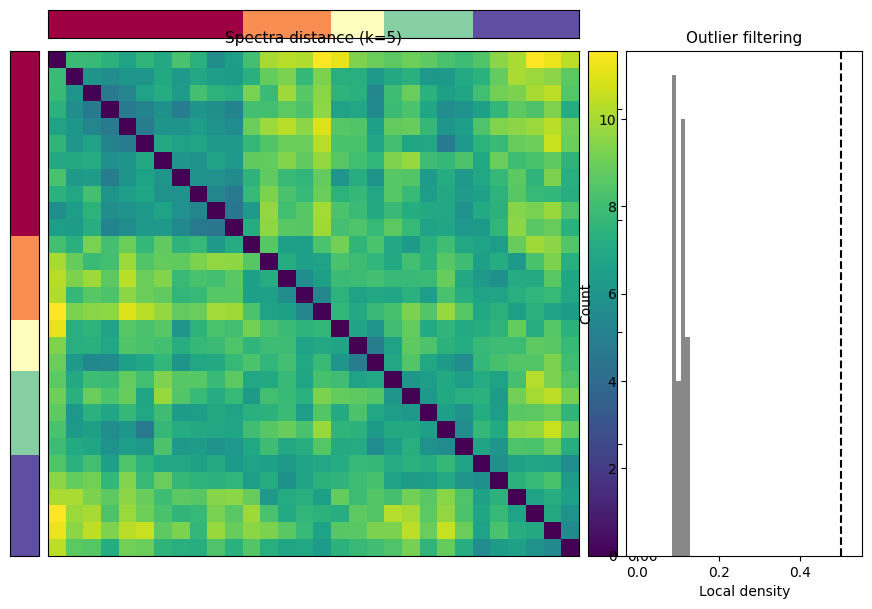

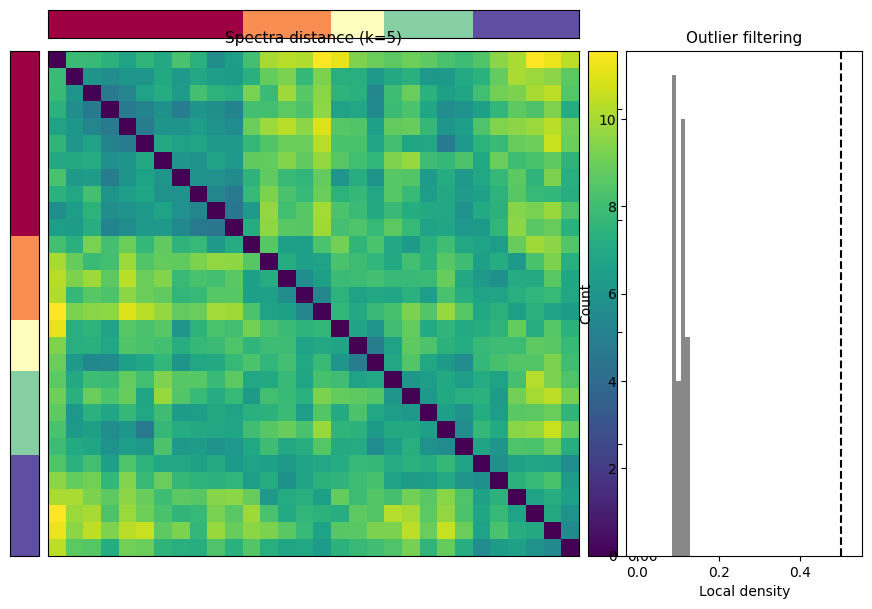

In [10]:
fig = result.plot_clustergram()
fig

## Choosing $k$ with `k_selection`

In real applications you typically don't know the right number of
factors. [`k_selection`](#mofaflex.tl.k_selection) sweeps `fit_consensus`
across a range of $k$ values and returns a
[`KSelectionResult`](#mofaflex.tl.KSelectionResult) with stability
(silhouette score on the consensus clustering) and reconstruction
error per $k$.

The factory it takes is a *one-argument* callable `k -> MOFAFLEX` that
constructs a fresh template with the requested number of factors.

In [11]:
def k_factory(k):
    return terms.MofaFlex(
        n_factors=k,
        nonnegative_factors=True,
        nonnegative_weights=True,
    )


sweep = k_selection(
    k_factory,
    data,
    k_values=[3, 4, 5, 6, 7],
    n_runs=6,
    density_threshold=0.5,
    seed=7,
    fit_kwargs={
        "max_epochs": 200,
        "device": "cpu",
        "lr": 0.01,
        "early_stopper_patience": 20,
        "save_path": False,
    },
    show_progress=False,
)

INFO	No likelihoods provided. Using inferred likelihoods: view_0: Normal; view_1: Normal


INFO	Initializing factors using 'random' method...


  0%|          | 0/200 [00:00<?, ?epoch/s]

INFO	No likelihoods provided. Using inferred likelihoods: view_0: Normal; view_1: Normal


INFO	Initializing factors using 'random' method...


...

INFO	Initializing factors using 'random' method...


  0%|          | 0/200 [00:00<?, ?epoch/s]

INFO	No likelihoods provided. Using inferred likelihoods: view_0: Normal; view_1: Normal


INFO	Initializing factors using 'random' method...


  0%|          | 0/200 [00:00<?, ?epoch/s]

In [12]:
pd.DataFrame(
    {
        "stability": sweep.stability,
        "reconstruction_error": sweep.reconstruction_error,
    }
)

,stability,reconstruction_error
3,0.061083,14783.317474
4,0.122080,12984.942179
5,0.093030,11732.244934
6,0.100825,10785.568057
7,0.103121,10191.975428


The plotnine version of the diagnostic uses faceted twin axes:

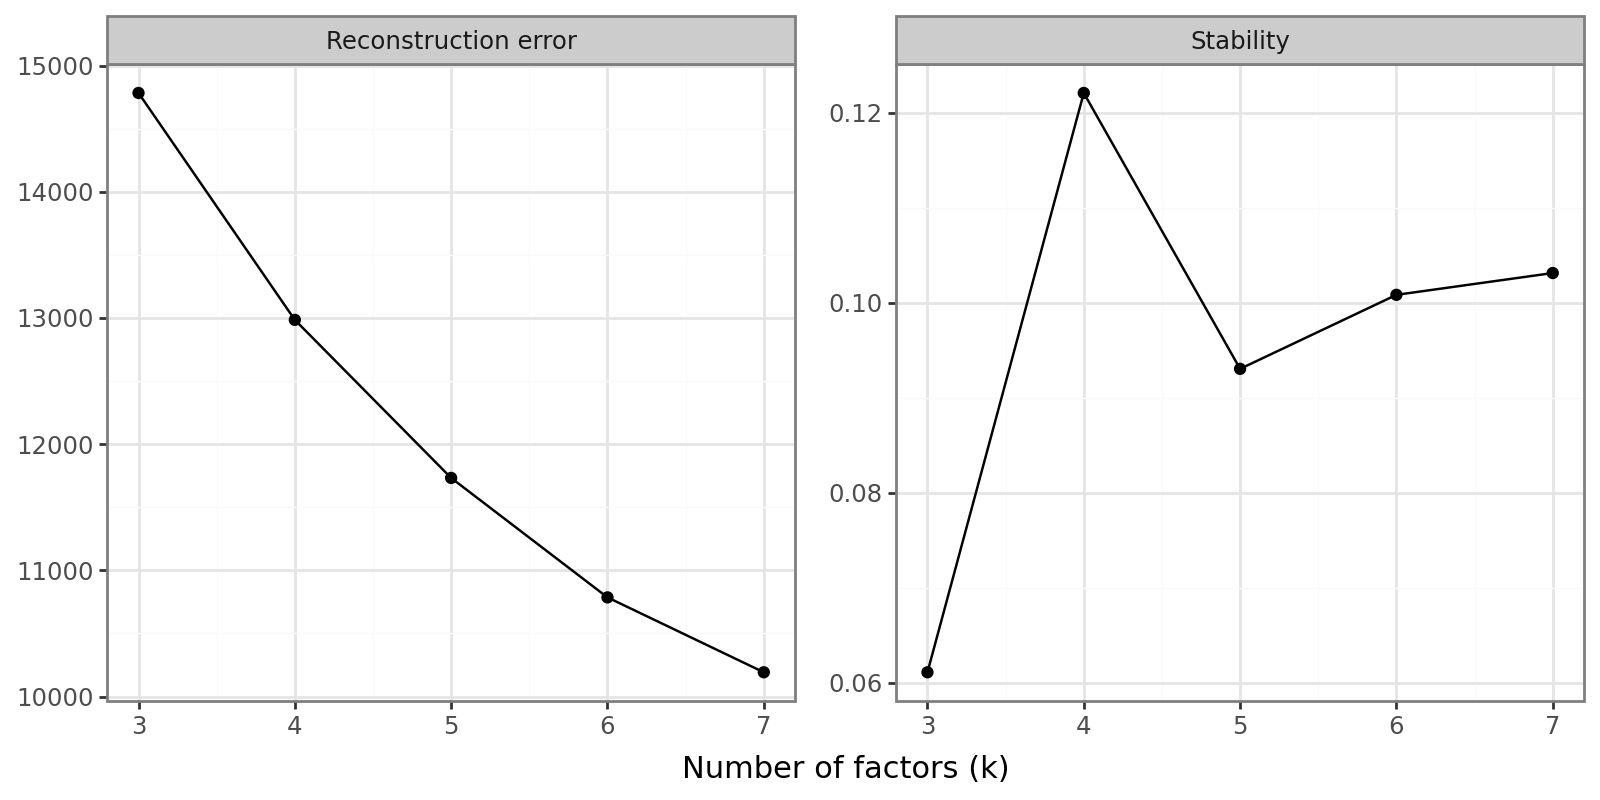

In [13]:
sweep.plot()

…and there is a matplotlib version that mirrors the cNMF paper figure
exactly (stability in blue on the left axis, reconstruction error in
red on the right axis):

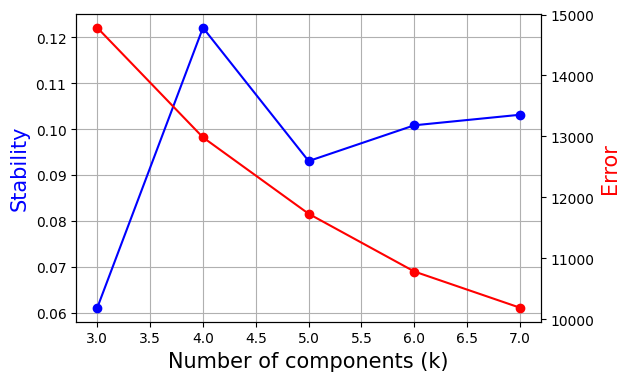

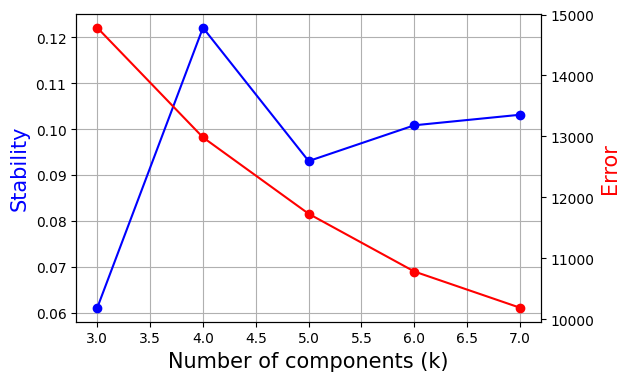

In [14]:
sweep.plot_cnmf()

The standard cNMF rule of thumb is to pick the smallest $k$ at which
**stability plateaus near its maximum** and **reconstruction error has
stopped dropping appreciably**. The two metrics often disagree —
reconstruction error decreases monotonically with $k$, while stability
typically peaks near the true rank — so the right choice is usually
the elbow of the stability curve, not its global maximum.

In a real workflow you would also want to bump `n_runs` (we use a
small number here for speed) to get smoother curves before reading
off a final $k$.

## Using a chosen consensus model downstream

Once you've picked $k$, the corresponding `ConsensusResult` is already
sitting in `sweep.results[k]`. Its `consensus_factors` matrix is the
per-cell usage matrix and can be attached to an `AnnData.obsm` slot for
visualisation or clustering.

In [15]:
chosen = sweep.results[5]
print(f"chosen k={chosen.n_factors}, stability={chosen.stability:.4f}")
Z = chosen.consensus_factors["group_1"]
Z.head()

chosen k=5, stability=0.0930


,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
cell_0,3.734100,0.000000,0.000000,13.914778,0.0
cell_1,0.000000,9.432892,1.093239,1.251259,0.0
cell_2,0.000000,11.547651,0.000000,0.000000,0.0
cell_3,7.121742,0.000000,0.000000,6.651434,0.0
cell_4,5.462142,0.000000,4.390739,0.094653,0.0


In [16]:
# Stash the consensus usage matrix back on the AnnData object for
# downstream plotting (UMAP, clustering, etc.). We use view_0 here purely
# to have an AnnData to attach to.
adata = data["group_1"]["view_0"]
adata.obsm["X_consensus_mofa"] = Z.loc[adata.obs_names].to_numpy()
adata

AnnData object with n_obs × n_vars = 200 × 40
    obsm: 'X_consensus_mofa'

## Caveats and tips

- **Templates must be fully non-negative.** Pass
  `nonnegative_factors=True` *and* `nonnegative_weights=True`;
  `fit_consensus` will raise a `ValueError` otherwise.
- **`n_runs >= 2`** is required. The defaults of 30 (`fit_consensus`)
  and 20 (`k_selection`) are good starting points for real data.
- If density filtering removes too many spectra to form $k$ clusters,
  `fit_consensus` raises a `ValueError` — relax `density_threshold`
  (e.g. try `1.0` or `2.0`) or increase `n_runs`.
- Set `seed` for reproducibility: it controls both the per-replicate
  seeds and the k-means initialisation.
- For real data, prefer the GPU (`fit_kwargs={"device": "cuda", ...}`)
  and longer `max_epochs`; the small CPU values used in this vignette
  are tuned for a fast doc build, not for production fits.